In [29]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
!pip install streamlit pyngrok

In [2]:
#Load Dataset
df = pd.read_csv("student_performance.csv")

if len(df) > 1000:
    df = df.sample(1000, random_state=42)

df.head()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
6809,6810,5.9,73.9,6.2,72.4,B
32257,32258,18.1,100.0,6.4,97.7,A
1213,1214,21.3,71.8,6.3,100.0,A
740,741,2.1,70.4,4.6,67.0,C
27183,27184,3.7,81.0,8.6,48.8,D


In [5]:
#Data Exploration
display(df.head())
print("\n")
display(df.tail())
print("\n")
df.info()
print("\n")
display(df.describe())

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
6809,6810,5.9,73.9,6.2,72.4,B
32257,32258,18.1,100.0,6.4,97.7,A
1213,1214,21.3,71.8,6.3,100.0,A
740,741,2.1,70.4,4.6,67.0,C
27183,27184,3.7,81.0,8.6,48.8,D


,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
21379,21380,10.0,97.4,4.9,79.6,B
21523,21524,14.5,89.6,8.6,68.5,C
14807,14808,10.6,84.8,5.2,76.3,B
4890,4891,9.2,68.5,3.8,63.5,C
39578,39579,31.0,80.9,4.8,100.0,A




<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 6809 to 39578
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   student_id               1000 non-null   int64  
 1   weekly_self_study_hours  1000 non-null   float64
 2   attendance_percentage    1000 non-null   float64
 3   class_participation      1000 non-null   float64
 4   total_score              1000 non-null   float64
 5   grade                    1000 non-null   object 
dtypes: float64(4), int64(1), object(1)
memory usage: 54.7+ KB




,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20034.140000,14.863200,84.826500,5.939600,83.931000
std,11577.156965,6.859741,9.407921,1.974596,16.065676
min,41.000000,0.000000,53.800000,0.000000,31.900000
25%,9984.750000,10.100000,78.400000,4.600000,72.100000
50%,19996.500000,15.000000,85.000000,5.900000,88.400000
75%,30391.500000,19.500000,91.700000,7.400000,100.000000
max,39743.000000,40.000000,100.000000,10.000000,100.000000


In [6]:
#Missing Values & Duplicates
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
student_id                 0
weekly_self_study_hours    0
attendance_percentage      0
class_participation        0
total_score                0
grade                      0
dtype: int64

Duplicate Rows:
0


In [7]:
#Data Cleaning
df["grade"] = df["grade"].astype(str).str.strip()

print(df["grade"].unique())

['B' 'A' 'C' 'D' 'F']


In [8]:
#Validation Checks
print("Attendance Outliers:")
print(df[(df["attendance_percentage"] < 0) |
         (df["attendance_percentage"] > 100)])

print("Score Outliers:")
print(df[(df["total_score"] < 0) |
         (df["total_score"] > 100)])

Attendance Outliers:
Empty DataFrame
Columns: [student_id, weekly_self_study_hours, attendance_percentage, class_participation, total_score, grade]
Index: []
Score Outliers:
Empty DataFrame
Columns: [student_id, weekly_self_study_hours, attendance_percentage, class_participation, total_score, grade]
Index: []


In [9]:
print("Mean:", df["total_score"].mean())
print("Median:", df["total_score"].median())
print("Mode:", df["total_score"].mode()[0])
print("Variance:", df["total_score"].var())
print("Standard Deviation:", df["total_score"].std())

Mean: 83.931
Median: 88.4
Mode: 100.0
Variance: 258.1059449449454
Standard Deviation: 16.065675987799125


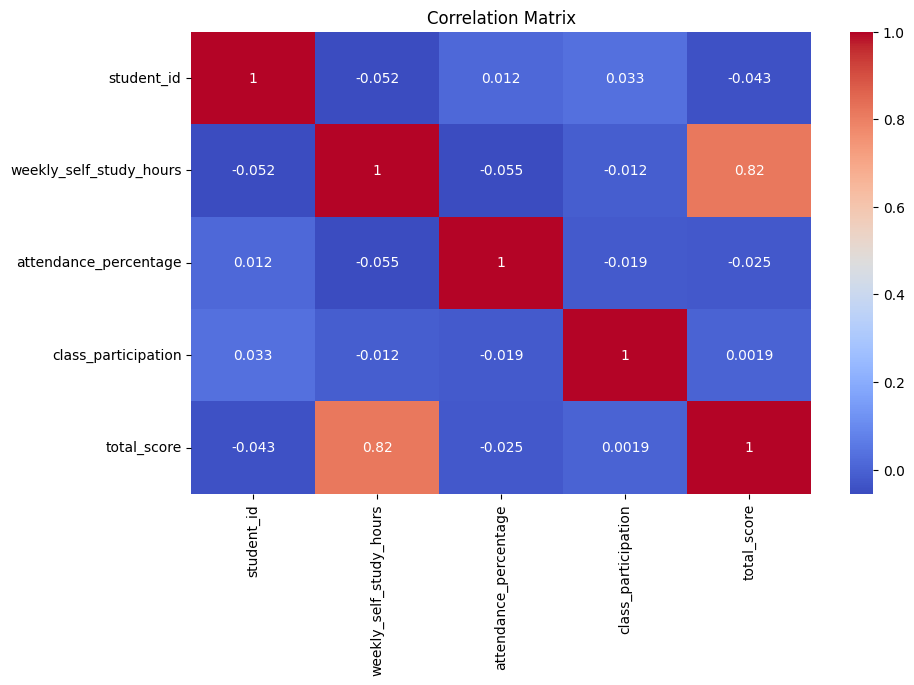

In [10]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [11]:
fig = px.histogram(
    df,
    x="grade",
    title="Grade Distribution",
    color="grade"
)
fig.show()

In [15]:
fig = px.scatter(
    df,
    x="attendance_percentage",
    y="total_score",
    color="grade",
    title="Attendance vs Total Score",
    hover_data=["student_id"]
)
fig.show()

In [13]:
avg_score = df.groupby("grade")["total_score"].mean().reset_index()

fig = px.bar(
    avg_score,
    x="grade",
    y="total_score",
    color="grade",
    title="Average Score by Grade"
)
fig.show()

In [17]:
subject_scores = df.groupby("grade")["total_score"].mean().reset_index()

fig = px.bar(
    subject_scores,
    x="grade",
    y="total_score",
    color="grade",
    title="Average Score by Grade"
)
fig.show()

In [18]:
fig = px.box(
    df,
    y="attendance_percentage",
    title="Attendance Distribution"
)
fig.show()

In [19]:
grade_count = df["grade"].value_counts().reset_index()
grade_count.columns = ["Grade", "Count"]

fig = px.pie(
    grade_count,
    names="Grade",
    values="Count",
    title="Grade Percentage"
)
fig.show()

In [21]:
top_students = df.nlargest(10, "total_score")

fig = px.bar(
    top_students,
    x="student_id",
    y="total_score",
    color="total_score",
    title="Top 10 Students"
)
fig.show()

In [36]:
%%writefile app.py

import streamlit as st
import pandas as pd
import plotly.express as px

# ==========================
# Page Configuration
# ==========================
st.set_page_config(
    page_title="LearnLytics Dashboard",
    page_icon="📚",
    layout="wide"
)

# ==========================
# Load Data
# ==========================
@st.cache_data
def load_data():
    return pd.read_csv("student_performance.csv")

df = load_data()

# ==========================
# Sidebar
# ==========================
st.sidebar.title("📊 Filters")

grade_filter = st.sidebar.multiselect(
    "Select Grade",
    options=sorted(df["grade"].unique()),
    default=sorted(df["grade"].unique())
)

filtered_df = df[df["grade"].isin(grade_filter)]

st.sidebar.markdown("---")
st.sidebar.write("Total Records:", len(filtered_df))
st.sidebar.write("Total Grades:", filtered_df["grade"].nunique())

# ==========================
# Header
# ==========================
st.title("📚 LearnLytics - Student Performance Dashboard")
st.markdown("Analyze student performance, attendance, and grades interactively.")

# ==========================
# KPI Metrics
# ==========================
col1, col2, col3 = st.columns(3)

col1.metric(
    "👨‍🎓 Total Students",
    len(filtered_df)
)

col2.metric(
    "📈 Average Score",
    round(filtered_df["total_score"].mean(), 2)
)

col3.metric(
    "📝 Average Attendance",
    f"{round(filtered_df['attendance_percentage'].mean(),2)}%"
)

# ==========================
# Scatter Plot
# ==========================
st.subheader("📌 Attendance vs Total Score")

plot_df = filtered_df.copy()

if len(plot_df) > 1000:
    plot_df = plot_df.sample(1000, random_state=42)

fig1 = px.scatter(
    plot_df,
    x="attendance_percentage",
    y="total_score",
    color="grade",
    hover_data=["student_id"],
    title="Attendance vs Score"
)

st.plotly_chart(fig1, use_container_width=True)

# ==========================
# Grade Distribution
# ==========================
st.subheader("📊 Grade Distribution")

fig2 = px.histogram(
    filtered_df,
    x="grade",
    color="grade",
    title="Grade Distribution"
)

st.plotly_chart(fig2, use_container_width=True)

# ==========================
# Grade Percentage
# ==========================
st.subheader("🥧 Grade Percentage")

grade_count = filtered_df["grade"].value_counts().reset_index()
grade_count.columns = ["Grade", "Count"]

fig3 = px.pie(
    grade_count,
    names="Grade",
    values="Count",
    title="Grade Share"
)

st.plotly_chart(fig3, use_container_width=True)

# ==========================
# Top Students
# ==========================
st.subheader("🏆 Top 10 Students")

top_students = filtered_df.nlargest(10, "total_score")

fig4 = px.bar(
    top_students,
    x="student_id",
    y="total_score",
    color="total_score",
    title="Top 10 Students"
)

st.plotly_chart(fig4, use_container_width=True)

# ==========================
# Attendance Distribution
# ==========================
st.subheader("📅 Attendance Distribution")

fig5 = px.box(
    filtered_df,
    y="attendance_percentage",
    title="Attendance Distribution"
)

st.plotly_chart(fig5, use_container_width=True)

# ==========================
# Average Score by Grade
# ==========================
st.subheader("📈 Average Score by Grade")

avg_score = (
    filtered_df.groupby("grade")["total_score"]
    .mean()
    .reset_index()
)

fig6 = px.bar(
    avg_score,
    x="grade",
    y="total_score",
    color="grade",
    title="Average Score by Grade"
)

st.plotly_chart(fig6, use_container_width=True)

# ==========================
# Data Table
# ==========================
st.subheader("📄 Student Dataset")

st.write(f"Showing first 100 rows out of {len(filtered_df)} records")

st.dataframe(
    filtered_df.head(100),
    use_container_width=True
)

# ==========================
# Footer
# ==========================
st.markdown("---")
st.markdown(
    "### 📚 LearnLytics Dashboard\n"
    "Built using Streamlit, Pandas, and Plotly."
)

Overwriting app.py


In [37]:
!streamlit run app.py &>/content/logs.txt &

In [38]:
from pyngrok import ngrok

# Replace 'YOUR_AUTHTOKEN' with your actual ngrok authtoken
# You can get your authtoken from https://dashboard.ngrok.com/get-started/your-authtoken
ngrok.set_auth_token("YOUR_AUTHTOKEN")

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://sitter-atlas-canopy.ngrok-free.dev" -> "http://localhost:8501"
